In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Imports successful!")

Imports successful!


In [2]:
df = pd.read_csv('../data/raw/Data/AAPL.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [3]:
print(df.info())
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB
None
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


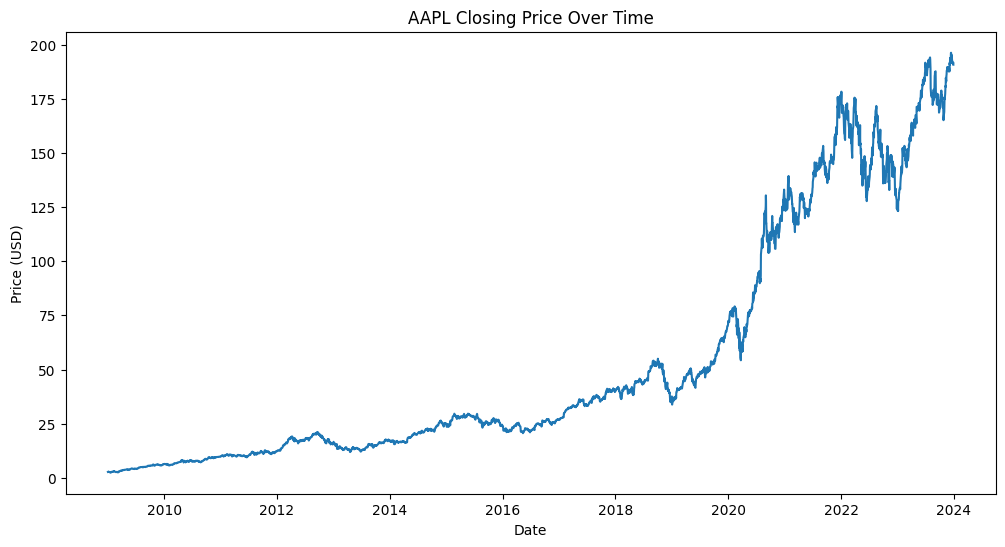

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'])
plt.title('AAPL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()

In [6]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

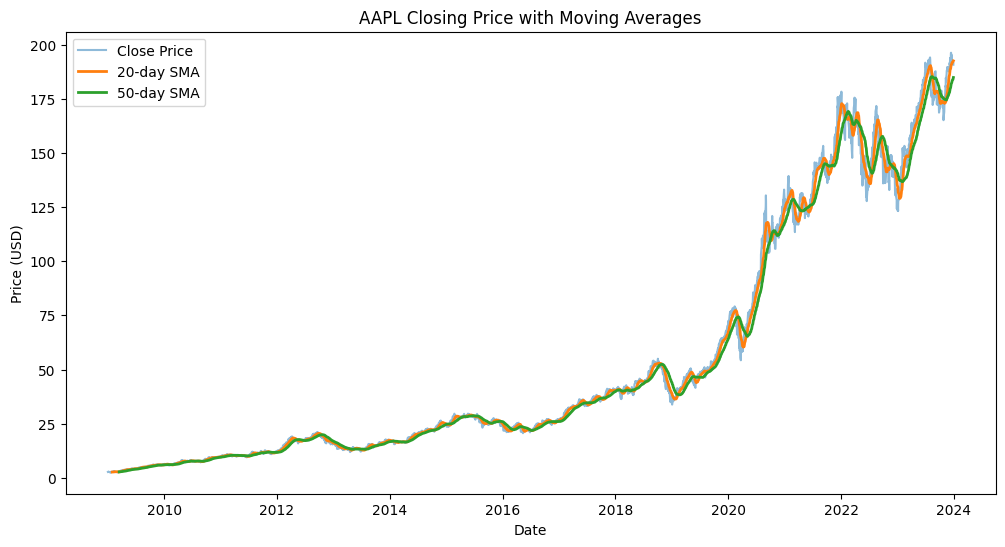

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Close Price', alpha=0.5)
plt.plot(df.index, df['SMA_20'], label='20-day SMA', linewidth=2)
plt.plot(df.index, df['SMA_50'], label='50-day SMA', linewidth=2)
plt.title('AAPL Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [8]:
# Calculate RSI manually
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = calculate_rsi(df['Close'])

In [9]:
# Calculate MACD
ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26
df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Histogram'] = df['MACD'] - df['Signal']

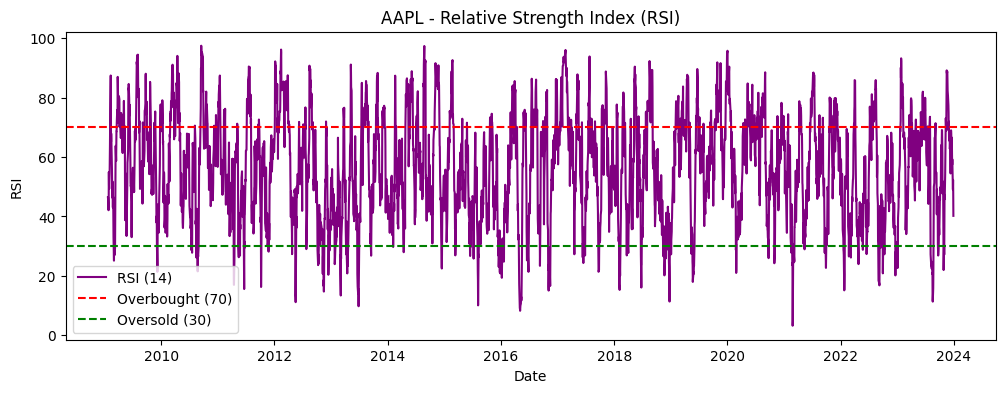

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['RSI'], label='RSI (14)', color='purple')
plt.axhline(y=70, color='r', linestyle='--', label='Overbought (70)')
plt.axhline(y=30, color='g', linestyle='--', label='Oversold (30)')
plt.title('AAPL - Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.show()


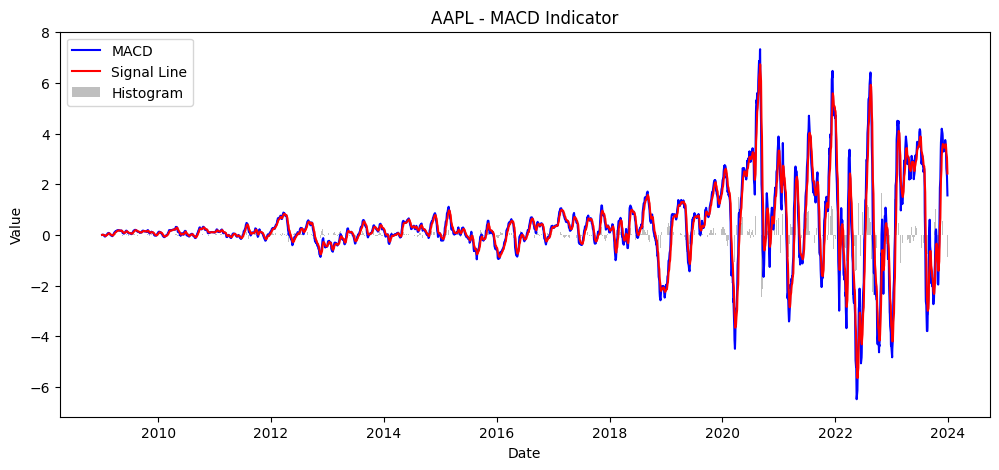

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['MACD'], label='MACD', color='blue')
plt.plot(df.index, df['Signal'], label='Signal Line', color='red')
plt.bar(df.index, df['MACD_Histogram'], label='Histogram', color='gray', alpha=0.5)
plt.title('AAPL - MACD Indicator')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

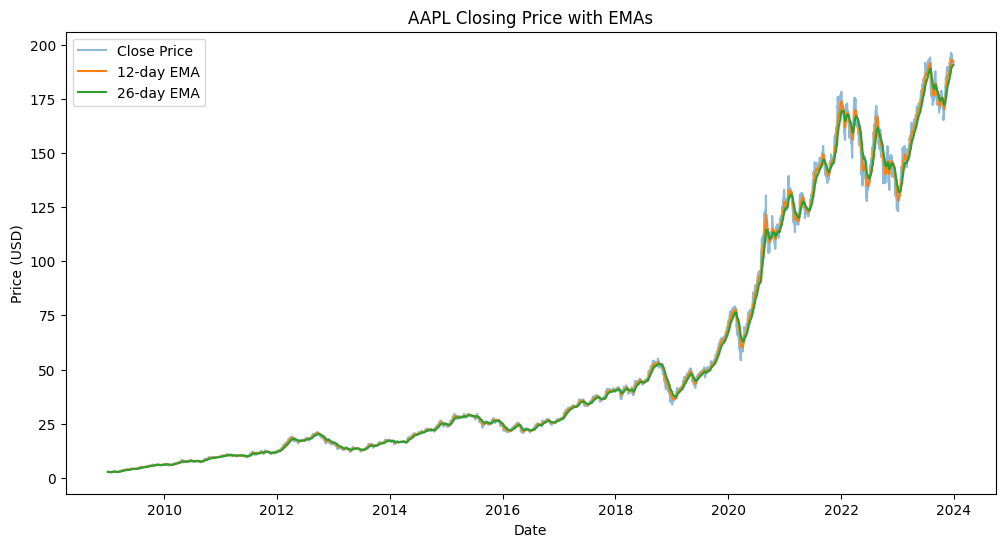

In [12]:
# Calculate Exponential Moving Averages
df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()

# Plot EMAs
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Close Price', alpha=0.5)
plt.plot(df.index, df['EMA_12'], label='12-day EMA')
plt.plot(df.index, df['EMA_26'], label='26-day EMA')
plt.title('AAPL Closing Price with EMAs')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [13]:
import pynance as pn
print("PyNance imported!")

PyNance imported!


In [14]:
import yfinance as yf

# Download AAPL data
aapl = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
aapl.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085091,73.386408,71.631537,71.631537,132079200


In [15]:
import pynance as pn
print(dir(pn))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__']


In [16]:
print([x for x in dir(pn) if 'return' in x.lower() or 'volatility' in x.lower() or 'sharpe' in x.lower()])

[]


In [17]:
import pynance as pn
import yfinance as yf

# Download data
aapl = yf.download('AAPL', start='2020-01-01', end='2024-01-01')

# Daily returns
daily_ret = aapl['Close'].pct_change().dropna()

# Compute metrics – ensure they are scalars
annual_return = (daily_ret.mean() * 252)
annual_vol = (daily_ret.std() * (252 ** 0.5))
sharpe_ratio = annual_return / annual_vol

# Convert to float if they are pandas Series (e.g., with one element)
if hasattr(annual_return, 'iloc'):
    annual_return = annual_return.iloc[0]
if hasattr(annual_vol, 'iloc'):
    annual_vol = annual_vol.iloc[0]
if hasattr(sharpe_ratio, 'iloc'):
    sharpe_ratio = sharpe_ratio.iloc[0]

print(f"Annual Return: {annual_return:.2%}")
print(f"Volatility: {annual_vol:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

[*********************100%***********************]  1 of 1 completed

Annual Return: 29.90%
Volatility: 33.57%
Sharpe Ratio: 0.89


In [18]:
import talib
print(talib.__version__)

0.6.8


In [19]:
import talib
import yfinance as yf
import numpy as np

# Download data
aapl = yf.download('AAPL', start='2020-01-01', end='2024-01-01')

# Extract close prices, drop NaNs, flatten to 1D, convert to float64
close_array = aapl['Close'].dropna().values.flatten().astype(np.float64)

print("Shape:", close_array.shape)  # Should be (1006,) not (1006,1)

# TA‑Lib indicators
aapl['SMA_20'] = talib.SMA(close_array, timeperiod=20)
aapl['EMA_12'] = talib.EMA(close_array, timeperiod=12)
aapl['RSI'] = talib.RSI(close_array, timeperiod=14)

macd, signal, hist = talib.MACD(close_array, fastperiod=12, slowperiod=26, signalperiod=9)
aapl['MACD'] = macd
aapl['MACD_Signal'] = signal
aapl['MACD_Hist'] = hist

# Verify
aapl[['Close', 'SMA_20', 'EMA_12', 'RSI', 'MACD', 'MACD_Signal']].tail()

[*********************100%***********************]  1 of 1 completed


Shape: (1006,)


Price,Close,SMA_20,EMA_12,RSI,MACD,MACD_Signal
Ticker,AAPL,,,,,
Date,,,,,,
2023-12-22,191.609497,191.677262,192.735104,54.672888,2.630679,3.232230
2023-12-26,191.065109,191.838585,192.478181,53.089998,2.302595,3.046303
2023-12-27,191.164093,191.974671,192.276014,53.354439,2.027205,2.842483
2023-12-28,191.589676,192.183007,192.170424,54.540996,1.822291,2.638445
2023-12-29,190.550446,192.310680,191.921196,51.121263,1.558078,2.422372


In [ ]:
import pynance as pn
print("PyNance imported successfully!")

# Use PyNance to fetch data
aapl_py = pn.data.get('AAPL', '2020-01-01', '2024-01-01')
aapl_py.head()